In [1]:

from pathlib import Path


import matplotlib.pyplot as plt

import pandas as pd

from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from collections import Counter
from best_dialect_model import train_best_model, save_model, load_jsonl, prepare_split, derive_label_metadata, load_model

# Set paths
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "src" / "dialect_data"


In [2]:

# Load SNF datasets (assuming Swiss German dialects)
train_records = load_jsonl(DATA_DIR / "snf_train_train_all.jsonl")
valid_records = load_jsonl(DATA_DIR / "snf_train_valid.jsonl")
test_records = load_jsonl(DATA_DIR / "snf_test_test.jsonl")

# Load CV dataset (if needed)
train_records += load_jsonl(DATA_DIR / "cv_train_enriched.jsonl")
valid_records += load_jsonl(DATA_DIR / "cv_valid_enriched.jsonl")
test_records += load_jsonl(DATA_DIR / "cv_test_enriched.jsonl")

print(f"Train: {len(train_records)} records")
print(f"Valid: {len(valid_records)} records")
print(f"Test: {len(test_records)} records")


Train: 312898 records
Valid: 36263 records
Test: 38664 records


In [3]:

# Class distribution and labels
all_records = train_records + valid_records + test_records
class_counts = {}
for rec in all_records:
    cls = rec.get("class_nr")
    class_counts[cls] = class_counts.get(cls, 0) + 1

print("Class distribution:", class_counts)


Class distribution: {6: 35598, 5: 34058, 1: 36333, 0: 35615, 4: 38094, 3: 30816, 2: 36340, 7: 35265, 8: 35265, 9: 35265, 10: 35176}


In [4]:

label_ids, label_names = derive_label_metadata(train_records, valid_records, test_records)
print(f"Label IDs: {label_ids}")
print(f"Label names: {label_names}")

train_texts, train_labels, _ = prepare_split(train_records)
valid_texts, valid_labels, _ = prepare_split(valid_records)
test_texts, test_labels, _ = prepare_split(test_records)

print(f"Train: {len(train_texts)} texts")
print(f"Valid: {len(valid_texts)} texts")
print(f"Test: {len(test_texts)} texts")

# Preprocess texts: remove spaces
train_texts = [text.replace(" ", "") for text in train_texts]
valid_texts = [text.replace(" ", "") for text in valid_texts]
test_texts = [text.replace(" ", "") for text in test_texts]

print("Spaces removed from texts.")


Label IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Label names: ['Zürich', 'Innerschweiz', 'Wallis', 'Graubünden', 'Ostschweiz', 'Basel', 'Bern', 'Deutsch', 'Französisch', 'Italienisch', 'Englisch']
Train: 312849 texts
Valid: 36259 texts
Test: 38654 texts
Spaces removed from texts.


In [5]:

# Phoneme frequency distribution
all_train_text = ''.join(train_texts)
phoneme_counts = Counter(all_train_text)

# Filter out rare phonemes (appear < 100 times)
rare_phonemes = {phoneme for phoneme, count in phoneme_counts.items() if count < 100}
print(f"Removing {len(rare_phonemes)} rare phonemes.")

train_texts = [''.join(c for c in text if c not in rare_phonemes) for text in train_texts]
valid_texts = [''.join(c for c in text if c not in rare_phonemes) for text in valid_texts]
test_texts = [''.join(c for c in text if c not in rare_phonemes) for text in test_texts]

print("Rare phonemes removed.")


Removing 11 rare phonemes.
Rare phonemes removed.


In [6]:

MODEL_PATH = PROJECT_ROOT / "src" / "model" / "best_dialect_model.joblib"

if not MODEL_PATH.exists():
    # Train the best model
    model = train_best_model(train_texts, train_labels)
    # Save model
    save_model(model, PROJECT_ROOT / "src" / "model" / "best_dialect_model.joblib")


Model loaded from /home/kenfus/swiss-zero-shot-va-tts/src/model/best_dialect_model.joblib
Classification Report for Best Model:
              precision    recall  f1-score       support
0              0.375037  0.363300  0.369075   3515.000000
1              0.337855  0.375533  0.355699   3515.000000
2              0.701379  0.709163  0.705250   3514.000000
3              0.566332  0.465149  0.510778   3515.000000
4              0.536934  0.630725  0.580063   3515.000000
5              0.504164  0.482219  0.492948   3515.000000
6              0.521300  0.529161  0.525201   3515.000000
7              0.936672  0.925747  0.931178   3515.000000
8              0.975911  0.945900  0.960671   3512.000000
9              0.929101  0.961878  0.945205   3515.000000
10             0.958208  0.908495  0.932689   3508.000000
accuracy       0.663321  0.663321  0.663321      0.663321
macro avg      0.667536  0.663388  0.664432  38654.000000
weighted avg   0.667458  0.663321  0.664360  38654.000000
Co

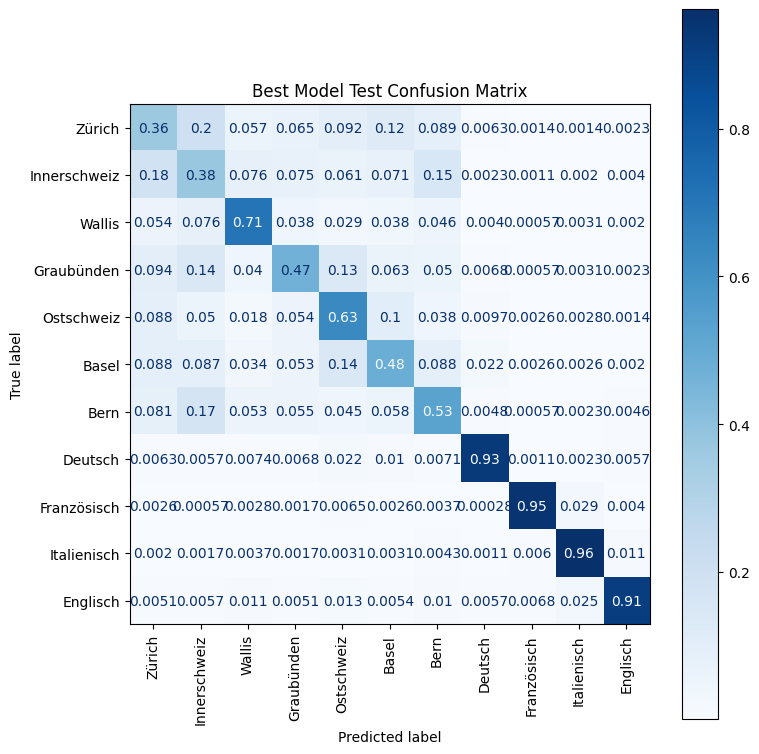

In [7]:
model = load_model(PROJECT_ROOT / "src" / "model" / "best_dialect_model.joblib")
# Evaluate on test
predictions = model.predict(test_texts)
report = classification_report(test_labels, predictions, output_dict=True)
print("Classification Report for Best Model:")
print(pd.DataFrame(report).transpose())

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    test_labels, predictions, normalize="true", cmap="Blues", ax=ax,
    display_labels=label_names, labels=label_ids, xticks_rotation="vertical"
)
fig.tight_layout()
plt.title("Best Model Test Confusion Matrix")
plt.savefig("best_dialect_model_confusion_matrix.png")
print("Confusion matrix saved to best_dialect_model_confusion_matrix.png")



In [ ]:
# Vary test data by actually adding a majority vote to it.
test_records = pd.DataFrame(test_records)
valid_records = pd.DataFrame(valid_records)

# Combine them
test_records = pd.concat([test_records, valid_records], ignore_index=True)
test_records

In [42]:
import random
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
random.seed(144333)

In [43]:
random.seed(144333)

ignored_classes = ['Deutsch', 'Französisch', 'Italienisch', 'Englisch']
test_records_df = test_records[~test_records['classname'].isin(ignored_classes)].copy()

def majority_vote_evaluation(n_samples):
    speaker_predictions = []
    speaker_true_labels = []
    
    for speaker, group in test_records_df.groupby('speaker_id'):
        if len(group) < 1:
            continue
        
        true_label = group['class_nr'].iloc[0]  # assume all same
        texts = group['phonemes'].tolist()
        
        # preprocess texts: remove spaces and rare phonemes
        texts = [text.replace(" ", "") for text in texts]
        texts = [''.join(c for c in text if c not in rare_phonemes) for text in texts]
        
        # sample min(n_samples, len(texts)) without replacement
        sampled_texts = random.sample(texts, min(n_samples, len(texts)))
        
        # Get probabilities
        probas = model.predict_proba(sampled_texts)
        
        # Average probabilities across samples
        mean_proba = probas.mean(axis=0)
        
        # Predict the class with highest average probability
        pred_mode = label_ids[mean_proba.argmax()]
        
        speaker_predictions.append(pred_mode)
        speaker_true_labels.append(true_label)
    
    # compute report
    report = classification_report(speaker_true_labels, speaker_predictions, output_dict=True, zero_division=0)
    print(f"Macro F1: {report['macro avg']['f1-score']:.4f}")
    
    # Filter labels to only include those present
    unique_labels = sorted(set(speaker_true_labels))
    label_ids_filtered = [lid for lid in label_ids if lid in unique_labels]
    label_names_filtered = [label_names[label_ids.index(lid)] for lid in label_ids_filtered]
    
    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 8))
    ConfusionMatrixDisplay.from_predictions(
        speaker_true_labels, speaker_predictions, normalize="true", cmap="Blues", ax=ax,
        display_labels=label_names_filtered, labels=label_ids_filtered, xticks_rotation="vertical"
    )
    fig.tight_layout()
    plt.title(f"Majority Vote Confusion Matrix (n={n_samples}, probability-weighted)")
    plt.savefig(f"src/best_model_metrics/majority_vote_confusion_matrix_n{n_samples}.png")
    print(f"Confusion matrix saved to majority_vote_confusion_matrix_n{n_samples}.png")
    
    return speaker_true_labels, speaker_predictions

Macro F1: 0.6073
Confusion matrix saved to majority_vote_confusion_matrix_n3.png
Macro F1: 0.7658
Confusion matrix saved to majority_vote_confusion_matrix_n5.png
Macro F1: 0.7826
Confusion matrix saved to majority_vote_confusion_matrix_n7.png
Macro F1: 0.8442
Confusion matrix saved to majority_vote_confusion_matrix_n8.png
Macro F1: 0.8503
Confusion matrix saved to majority_vote_confusion_matrix_n9.png
Macro F1: 0.8166
Confusion matrix saved to majority_vote_confusion_matrix_n10.png
Macro F1: 0.8407
Confusion matrix saved to majority_vote_confusion_matrix_n11.png
Macro F1: 0.8352
Confusion matrix saved to majority_vote_confusion_matrix_n12.png
Macro F1: 0.8330
Confusion matrix saved to majority_vote_confusion_matrix_n13.png
Macro F1: 0.8531
Confusion matrix saved to majority_vote_confusion_matrix_n15.png
Macro F1: 0.8335
Confusion matrix saved to majority_vote_confusion_matrix_n20.png


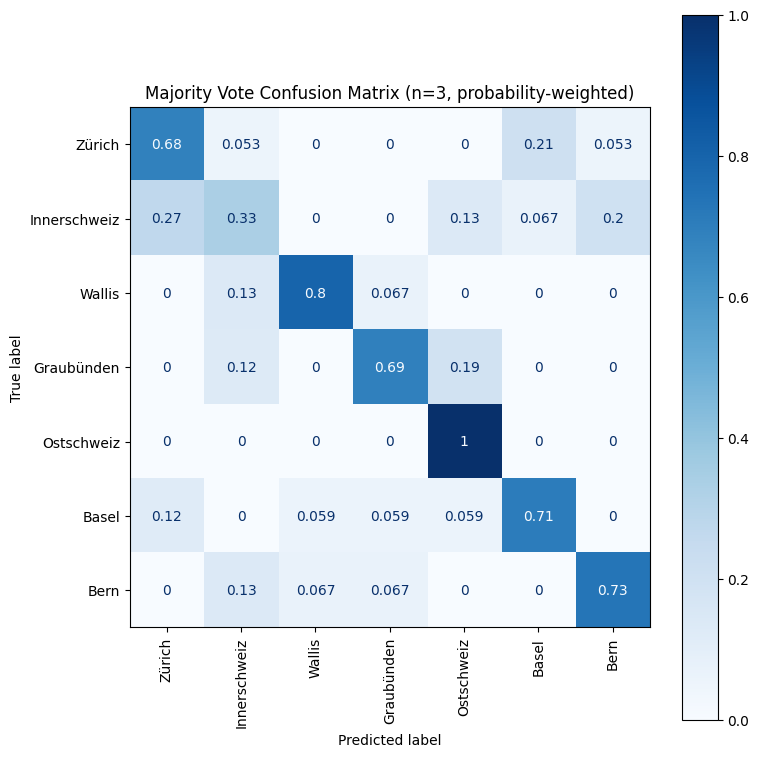

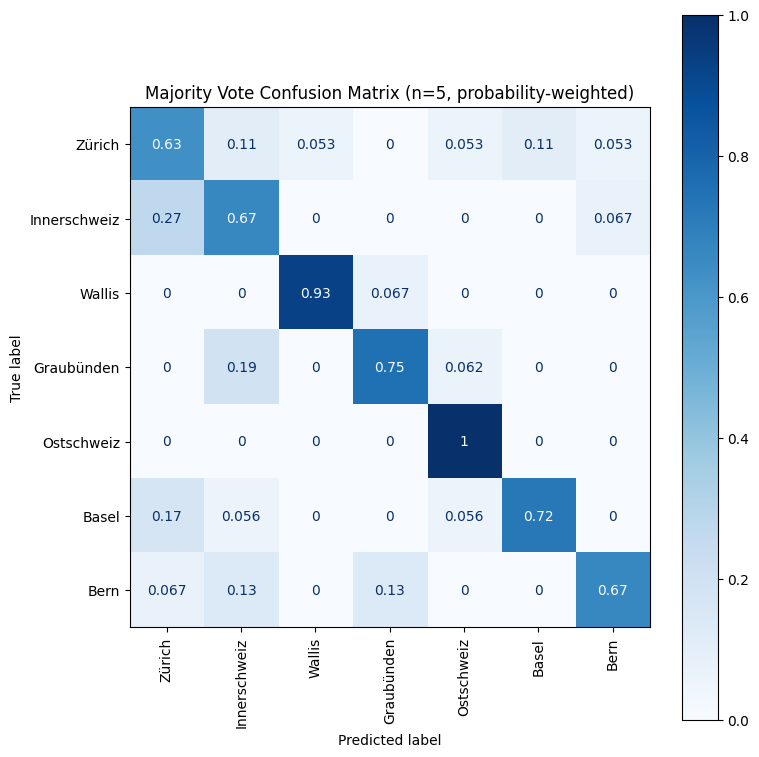

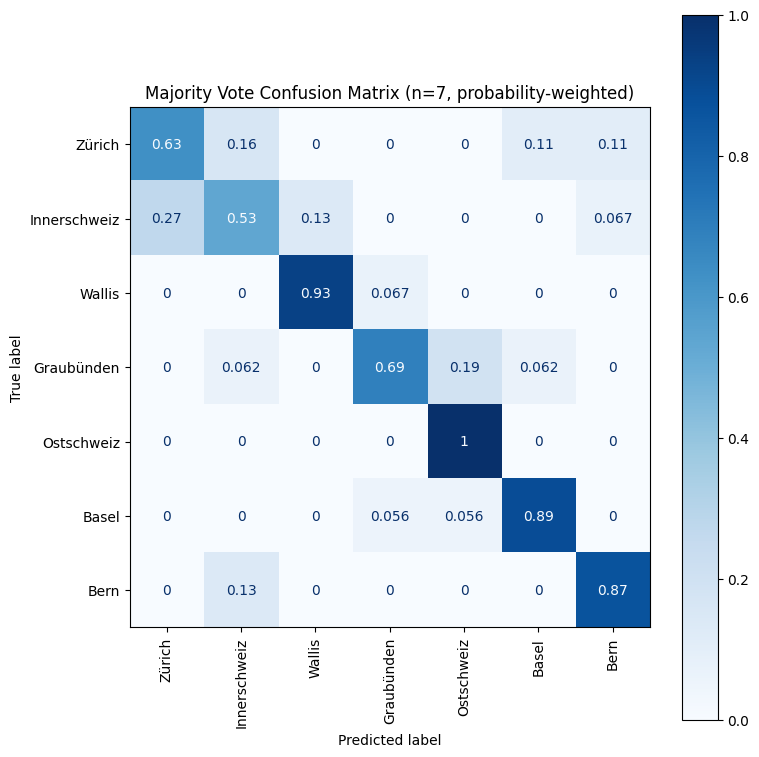

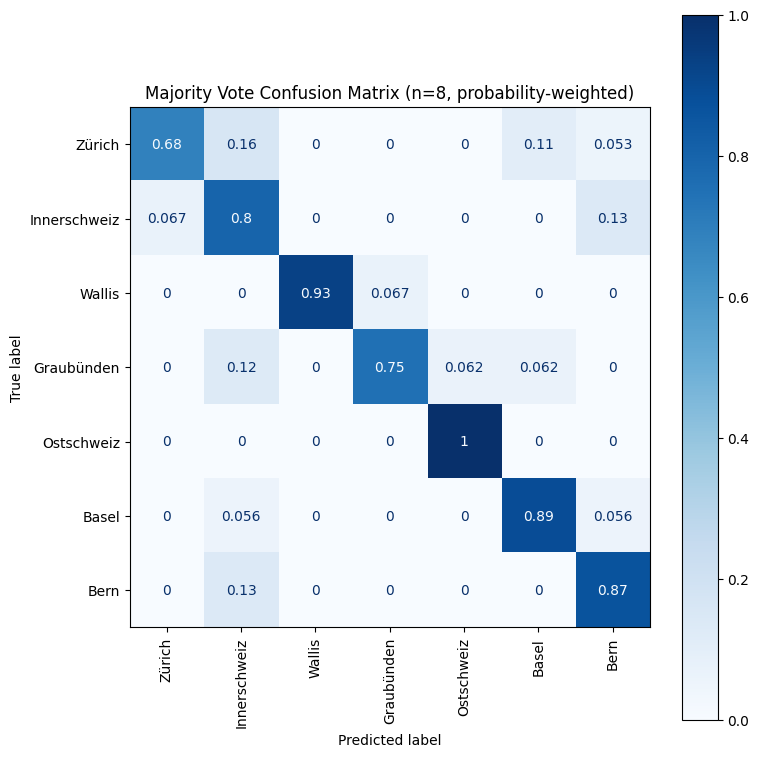

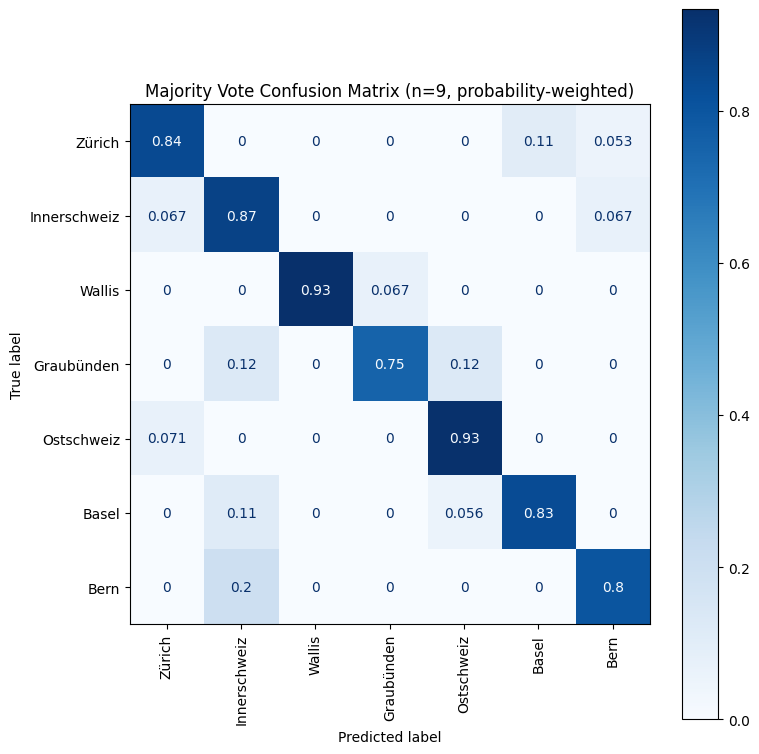

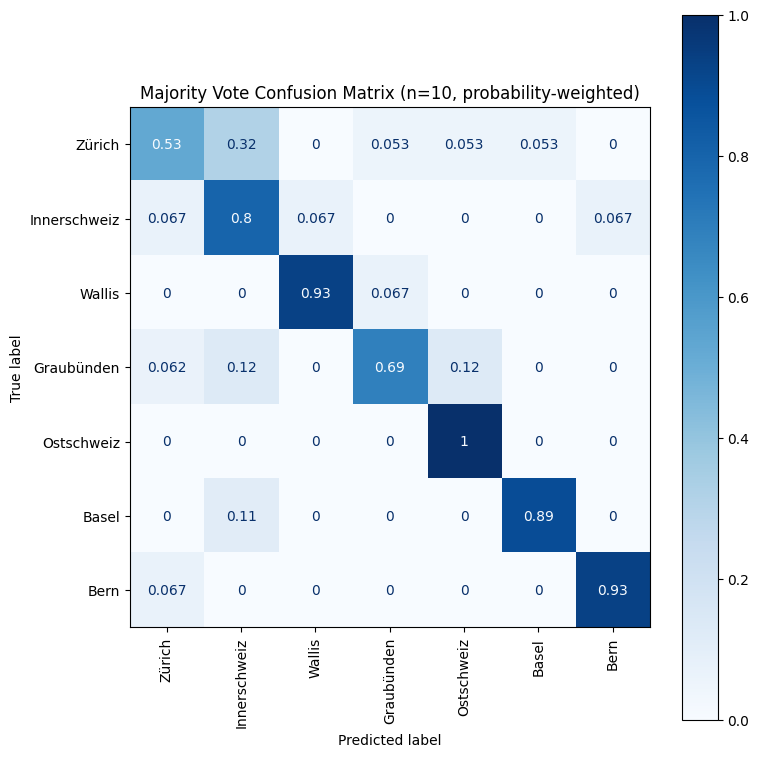

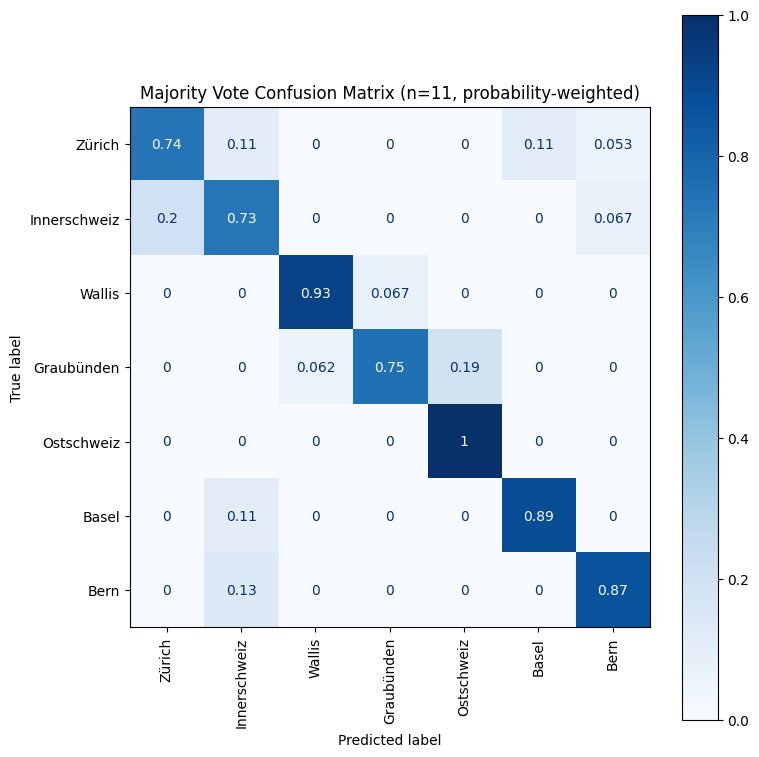

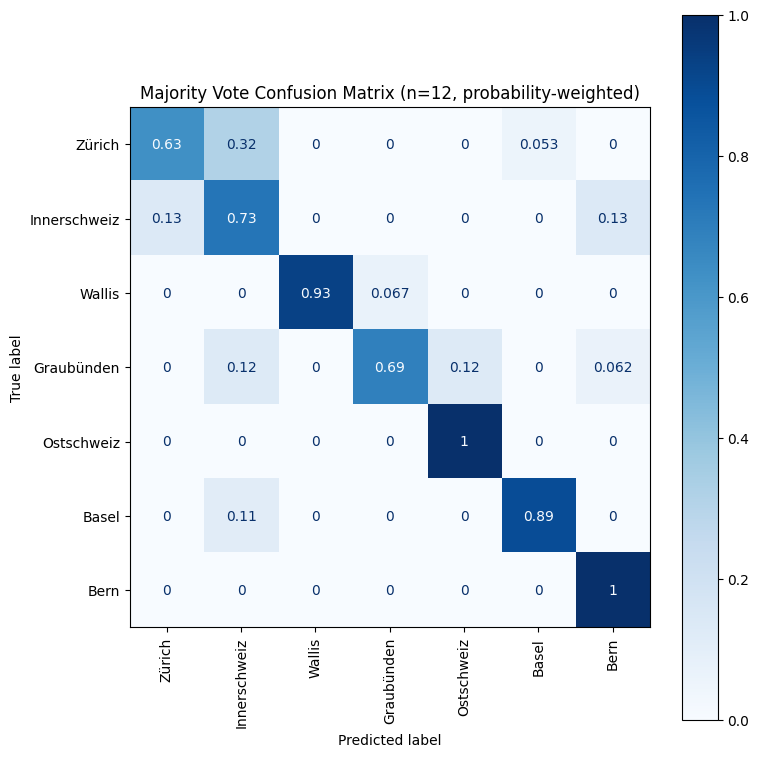

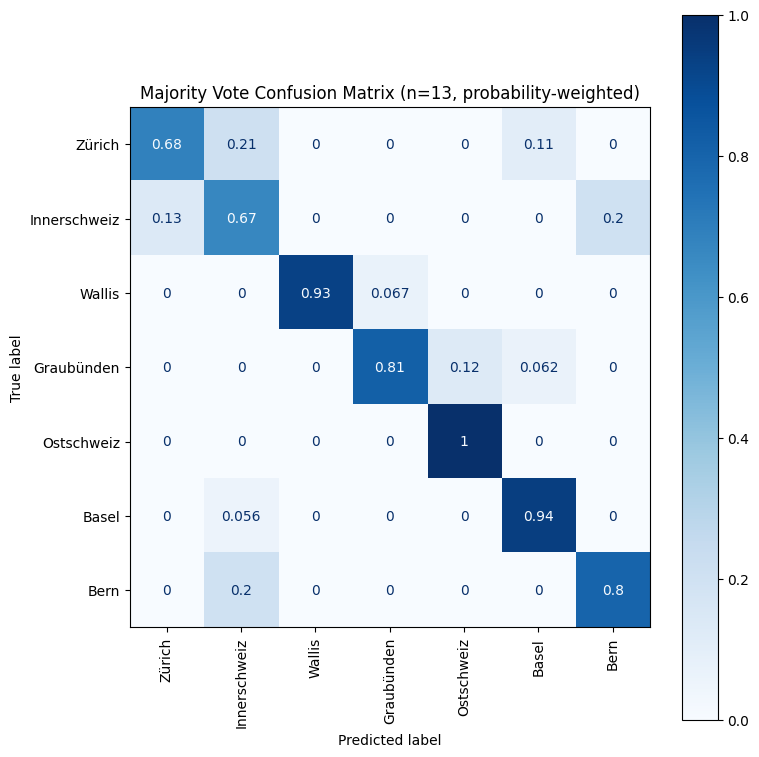

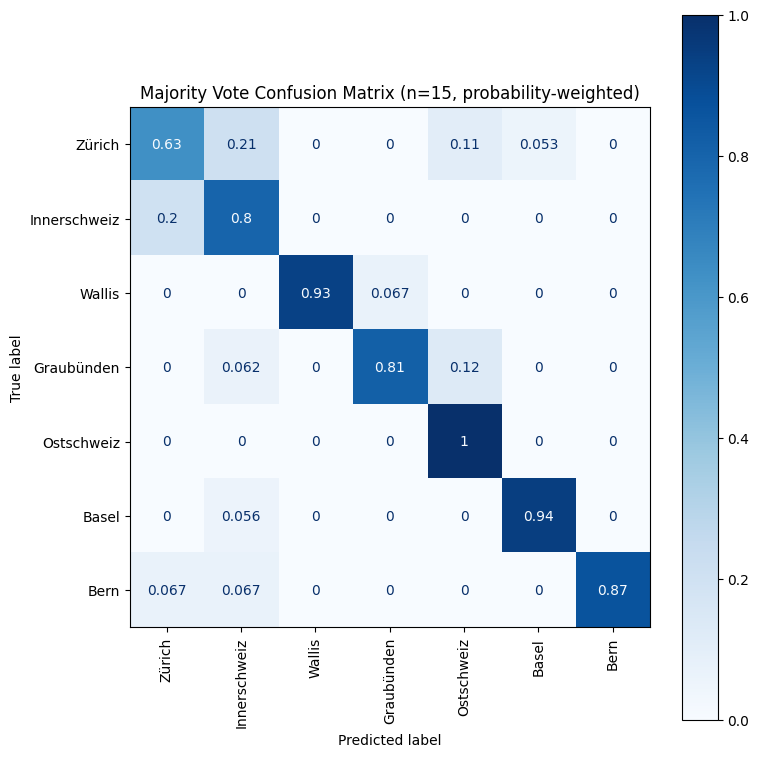

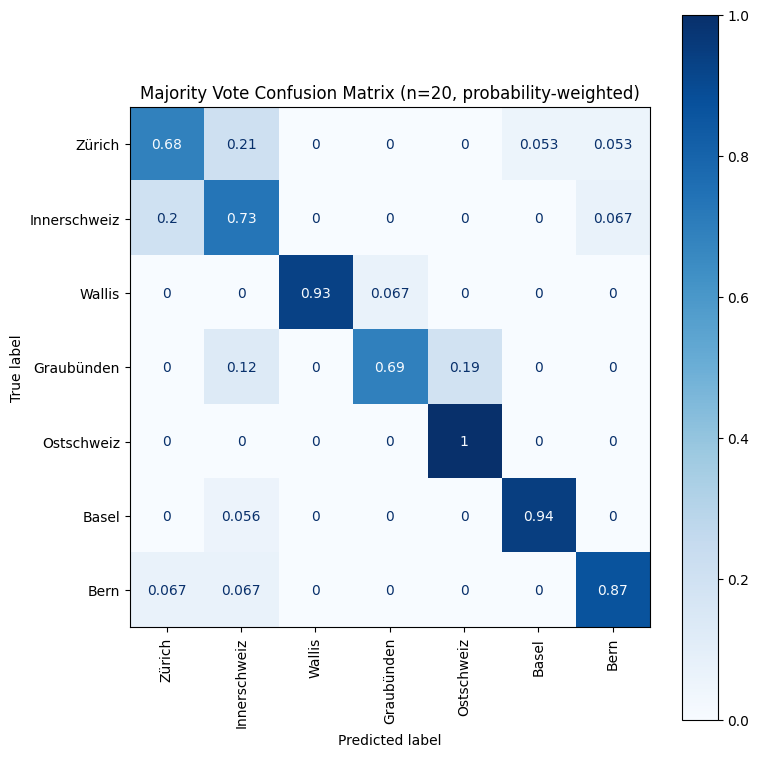

In [44]:
for n in [3, 5, 7, 8,9, 10,11,12,13,15, 20]:
    majority_vote_evaluation(n)